# Neural Autoencoder unsupervised forecast

Ноутбук реализует нейросетевой подход без учителя через автоэнкодер.

Основная идея:
- нейросеть обучается восстанавливать геолого-ориентированные признаки всех ячеек;
- из сжатого внутреннего представления строится score относительной перспективности;
- evidence cells используются только для диагностики качества результата, а не как обучающие метки.

В ноутбуке используются признаки по ячейкам:
- proximity и ранговые расстояния;
- буферные признаки;
- признаки узлов совместного проявления факторов;
- compact top-zones;
- метрики HitRate top 10/15%.

На выходе сохраняется только одна PNG-карта.

In [74]:
from pathlib import Path
import math
import random
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box
from shapely.ops import unary_union
from shapely.prepared import prep
from pyproj import CRS

from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.ndimage import maximum_filter, label

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


# =========================
# CONFIG
# =========================
BASE_DIR = Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз")
SHP_DIR = BASE_DIR / "shp_dbf"
OUT_DIR = BASE_DIR / "neural_autoencoder_unsupervised_improved_result"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CELL_SIZE = 500

LAYER_MAP = {
    "mask": "svita_new",
    "facies": "fasii",
    "paleo": "gr_dol_vp_poly",
    "struct": "kory",
    "magm": "dayki_buf",
    "tect1": "glub_raz_nw",
    "tect2": "glub_r_nw",
}

EVIDENCE_POINT_LAYER_NAMES = ["result", "геохимическое_опробование"]
USE_EVIDENCE_POLYGONS = False
EVIDENCE_POLYGON_LAYER_NAMES = ["геохимические ореолы", "привнос урана"]

# Масштабы для proximity-признаков.
SCALES = {
    "facies": 1200.0,
    "paleo": 1200.0,
    "struct": 900.0,
    "magm": 900.0,
    "tect1": 1000.0,
    "tect2": 1000.0,
}
BUFFER_DISTANCES = [1000, 1500]

# Нейросетевой автоэнкодер без учителя.
RUN_OPTIMIZATION = True
N_TRIALS = 10
TRIAL_ENSEMBLE_SIZE = 1
FINAL_ENSEMBLE_SIZE = 5

# Spatial CV можно выключить, если нужно быстрее.
RUN_SPATIAL_CHECK = True
N_SPATIAL_SPLITS = 5
SPATIAL_BLOCK_SIZE = 15  # в ячейках сетки

# Top-zone и визуализация.
SMOOTH_PASSES = 4
TOP_ZONE_Q = 0.996
NODE_TOP_ZONE_Q = 0.72
MAX_TOP_ZONE_SHARE = 0.006
LOCAL_MAX_SIZE = 5
MIN_TOP_COMPONENT_CELLS = 4
SHOW_POINTS = True

# Улучшения текущего автоэнкодера.
ADD_SPATIAL_CONTEXT_FEATURES = True
REMOVE_HIGHLY_CORRELATED_FEATURES = True
CORR_DROP_THRESHOLD = 0.94

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## 1. Вспомогательные функции

In [75]:
#
# Здесь специально используется мягкая загрузка слоёв:
# - читаются `*.shp`;
# - если CRS не найден, проверяются файлы вида `*_shp.pj4`, `.pj4`, `.qpj`, `.prj`;
# - геометрии не чинятся агрессивно через `buffer(0)`, чтобы не “съесть” маску.



def read_sidecar_proj4(path: Path):
    candidates = [
        path.with_name(path.stem + "_shp.pj4"),
        path.with_suffix(".pj4"),
        path.with_suffix(".qpj"),
        path.with_suffix(".prj"),
    ]
    for sidecar in candidates:
        if sidecar.exists():
            txt = sidecar.read_text(encoding="utf-8", errors="ignore").strip()
            if not txt:
                continue
            for line in txt.splitlines():
                line = line.strip()
                if line.lower().startswith("pj4="):
                    return line.split("=", 1)[1].strip()
            return txt
    return None


def repair_geometries(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()
    if "geometry" not in gdf:
        return gdf
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def finite_bounds(gdf: gpd.GeoDataFrame, layer_name: str = "layer"):
    if gdf is None or len(gdf) == 0:
        raise ValueError(f"Слой {layer_name} пуст после базовой очистки геометрий.")
    bounds = np.asarray(gdf.total_bounds, dtype=float)
    if len(bounds) != 4 or not np.all(np.isfinite(bounds)):
        raise ValueError(
            f"Некорректные total_bounds у слоя {layer_name}: {bounds}. "
            "Проверь CRS, исходную геометрию и sidecar-проекцию."
        )
    minx, miny, maxx, maxy = bounds.tolist()
    if maxx <= minx or maxy <= miny:
        raise ValueError(f"У слоя {layer_name} вырожденные границы: {(minx, miny, maxx, maxy)}")
    return minx, miny, maxx, maxy


def load_layer(path: Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    gdf = repair_geometries(gdf)
    if gdf.crs is None:
        proj4 = read_sidecar_proj4(path)
        if proj4:
            try:
                gdf = gdf.set_crs(CRS.from_user_input(proj4), allow_override=True)
            except Exception as e:
                print(f"Не удалось прочитать CRS из {path.name}: {e}")
    return gdf


def load_shapefiles(folder: Path):
    layers = {}
    for shp in sorted(folder.glob("*.shp")):
        try:
            layers[shp.stem] = load_layer(shp)
        except Exception as e:
            print(f"Не удалось загрузить {shp.name}: {e}")
    return layers


def to_crs_safe(gdf: gpd.GeoDataFrame, target_crs):
    if target_crs is None:
        return gdf
    if gdf.crs is None:
        return gdf.set_crs(target_crs, allow_override=True)
    if str(gdf.crs) == str(target_crs):
        return gdf
    return gdf.to_crs(target_crs)


def choose_target_crs(mask_gdf: gpd.GeoDataFrame):
    crs = mask_gdf.crs
    if crs is None:
        return None
    try:
        if crs.is_projected:
            return crs
    except Exception:
        pass
    try:
        utm = mask_gdf.estimate_utm_crs()
        if utm is not None:
            return utm
    except Exception:
        pass
    return crs


def harmonize_layers(layers: dict, target_crs):
    out = {}
    for name, gdf in layers.items():
        try:
            cur = to_crs_safe(gdf, target_crs)
            cur = repair_geometries(cur)
            out[name] = cur
        except Exception as e:
            print(f"Не удалось привести CRS слоя {name}: {e}")
            out[name] = gdf
    return out


def discover_point_layers(layers: dict, exclude_names=None):
    exclude_names = set(exclude_names or [])
    candidates = []
    for name, gdf in layers.items():
        if name in exclude_names or len(gdf) == 0:
            continue
        geom_types = set(gdf.geom_type.dropna().unique().tolist())
        if geom_types.issubset({"Point", "MultiPoint"}):
            candidates.append({
                "layer": name,
                "n": int(len(gdf)),
                "geom_types": sorted(list(geom_types)),
            })
    return candidates


def normalize_01(x):
    x = np.asarray(x, dtype=float)
    mn = np.nanmin(x)
    mx = np.nanmax(x)
    if not np.isfinite(mn) or not np.isfinite(mx) or mx <= mn:
        return np.zeros_like(x, dtype=float)
    return (x - mn) / (mx - mn)


def robust_normalize_01(x, q_low=0.02, q_high=0.98):
    x = np.asarray(x, dtype=float)
    lo = np.nanquantile(x, q_low)
    hi = np.nanquantile(x, q_high)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return normalize_01(x)
    y = (x - lo) / (hi - lo)
    return np.clip(y, 0.0, 1.0)


def distance_to_proximity(distances, scale):
    distances = np.asarray(distances, dtype=float)
    return 1.0 / (1.0 + distances / float(scale))


def build_grid(mask_gdf: gpd.GeoDataFrame, cell_size=500):
    minx, miny, maxx, maxy = finite_bounds(mask_gdf, "mask")
    mask_union = unary_union(mask_gdf.geometry)
    prepared_mask = prep(mask_union)

    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)
    rows = len(ys)
    cols = len(xs)
    if rows <= 0 or cols <= 0:
        raise ValueError(f"Некорректный размер сетки: rows={rows}, cols={cols}")

    geoms = []
    rr = []
    cc = []
    for r, y in enumerate(ys):
        for c, x in enumerate(xs):
            cell = box(x, y, x + cell_size, y + cell_size)
            if prepared_mask.intersects(cell):
                geoms.append(cell)
                rr.append(r)
                cc.append(c)

    if len(geoms) == 0:
        raise ValueError("После пересечения с маской сетка пустая. Проверь CRS слоёв и cell_size.")

    grid = gpd.GeoDataFrame({"row": rr, "col": cc}, geometry=geoms, crs=mask_gdf.crs)
    grid["cell_id"] = np.arange(len(grid))
    grid["centroid"] = grid.geometry.centroid
    return grid, (rows, cols), (minx, miny, maxx, maxy)


def compute_distance_feature(grid, source_gdf, scale):
    if source_gdf is None or len(source_gdf) == 0:
        dist = np.full(len(grid), np.nan, dtype=float)
        prox = np.zeros(len(grid), dtype=float)
        return dist, prox
    union_geom = unary_union(source_gdf.geometry)
    dist = grid["centroid"].distance(union_geom).to_numpy(dtype=float)
    prox = distance_to_proximity(dist, scale)
    return dist, prox


def compute_intersection_proximity(grid, gdf_a, gdf_b, scale=1200.0):
    """
    Признак близости к реальному геометрическому узлу пересечения двух слоёв.
    Работает для линий, полигонов и их границ. Если пересечения нет, возвращает нули.
    """
    try:
        if gdf_a is None or gdf_b is None or len(gdf_a) == 0 or len(gdf_b) == 0:
            return np.full(len(grid), np.nan, dtype=float), np.zeros(len(grid), dtype=float)
        geom_a = unary_union(gdf_a.geometry)
        geom_b = unary_union(gdf_b.geometry)
        inter = geom_a.intersection(geom_b)
        if inter is None or inter.is_empty:
            # Для полигональных слоёв иногда полезнее пересечение границ.
            try:
                inter = geom_a.boundary.intersection(geom_b.boundary)
            except Exception:
                pass
        if inter is None or inter.is_empty:
            return np.full(len(grid), np.nan, dtype=float), np.zeros(len(grid), dtype=float)
        dist = grid["centroid"].distance(inter).to_numpy(dtype=float)
        prox = distance_to_proximity(dist, scale)
        return dist, prox
    except Exception as e:
        print(f"Не удалось посчитать intersection proximity: {e}")
        return np.full(len(grid), np.nan, dtype=float), np.zeros(len(grid), dtype=float)


def smooth_on_regular_grid(arr: np.ndarray, valid_mask: np.ndarray, passes=2):
    work = arr.astype(float).copy()
    valid = valid_mask.astype(bool)

    for _ in range(int(passes)):
        num = np.zeros_like(work, dtype=float)
        den = np.zeros_like(work, dtype=float)
        finite_work = np.where(np.isfinite(work) & valid, work, 0.0)
        finite_mask = (np.isfinite(work) & valid).astype(float)

        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                shifted = np.roll(np.roll(finite_work, dr, axis=0), dc, axis=1)
                shifted_valid = np.roll(np.roll(finite_mask, dr, axis=0), dc, axis=1)

                if dr > 0:
                    shifted[:dr, :] = 0.0
                    shifted_valid[:dr, :] = 0.0
                elif dr < 0:
                    shifted[dr:, :] = 0.0
                    shifted_valid[dr:, :] = 0.0

                if dc > 0:
                    shifted[:, :dc] = 0.0
                    shifted_valid[:, :dc] = 0.0
                elif dc < 0:
                    shifted[:, dc:] = 0.0
                    shifted_valid[:, dc:] = 0.0

                num += shifted
                den += shifted_valid

        with np.errstate(divide="ignore", invalid="ignore"):
            smoothed = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
        work = np.where(valid, smoothed, np.nan)

    return work


def connected_component_filter_array(binary_arr, min_cells=2):
    binary_arr = np.asarray(binary_arr).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, ncomp = label(binary_arr, structure=structure)
    keep = np.zeros_like(binary_arr, dtype=np.uint8)
    for cid in range(1, ncomp + 1):
        comp = (labeled == cid)
        if comp.sum() >= min_cells:
            keep[comp] = 1
    return keep.astype(np.uint8)

## 2. Загрузка слоёв и построение сетки

In [76]:
layers_raw = load_shapefiles(SHP_DIR)
print("Слои:", sorted(layers_raw.keys()))

for logical_name, layer_name in LAYER_MAP.items():
    if layer_name not in layers_raw:
        raise FileNotFoundError(f"Не найден обязательный слой {logical_name}: {layer_name}")

mask_name = LAYER_MAP["mask"]
target_crs = choose_target_crs(layers_raw[mask_name])
layers = harmonize_layers(layers_raw, target_crs)

print("Используемые слои:", LAYER_MAP)
point_candidates = discover_point_layers(layers, exclude_names=set(LAYER_MAP.values()))
print("Точечные слои-кандидаты:", point_candidates)

grid, GRID_SHAPE, GRID_BOUNDS = build_grid(layers[LAYER_MAP["mask"]], CELL_SIZE)
rows, cols = GRID_SHAPE
minx, miny, maxx, maxy = GRID_BOUNDS

print("Ячеек в сетке:", len(grid))
print("Размер сетки (rows, cols):", GRID_SHAPE)
print("Границы:", GRID_BOUNDS)

Слои: ['dayki_buf', 'fasii', 'glub_r_nw', 'glub_raz_nw', 'gr_dol_vp_poly', 'kory', 'result', 'svita_new', 'геохимические ореолы', 'геохимическое_опробование', 'привнос урана']
Используемые слои: {'mask': 'svita_new', 'facies': 'fasii', 'paleo': 'gr_dol_vp_poly', 'struct': 'kory', 'magm': 'dayki_buf', 'tect1': 'glub_raz_nw', 'tect2': 'glub_r_nw'}
Точечные слои-кандидаты: [{'layer': 'result', 'n': 1332, 'geom_types': ['Point']}, {'layer': 'геохимическое_опробование', 'n': 76, 'geom_types': ['Point']}]
Ячеек в сетке: 15684
Размер сетки (rows, cols): (154, 145)
Границы: (536943.9873052016, 7843798.723451863, 609121.2875210745, 7920537.4178847205)


## 3. Расчёт признаков факторов

In [77]:
#
# Нейросеть получает геолого-ориентированный набор признаков по ячейкам:
# - близость к факторам;
# - ранговые расстояния;
# - бинарные буферы `500/1000/1500 м`;
# - несколько простых логических комбинаций.
#
# Дальше автоэнкодер без учителя учится сжимать и восстанавливать эти признаки.


# Базовые distance/proximity-признаки
for key in ["facies", "paleo", "struct", "magm", "tect1", "tect2"]:
    layer_name = LAYER_MAP[key]
    dist, prox = compute_distance_feature(grid, layers[layer_name], SCALES[key])
    grid[f"dist_{key}"] = dist
    grid[f"prox_{key}"] = prox

# Агрегированная тектоника: один общий tect_any вместо двух сильно дублирующих направлений.
grid["dist_tect_any"] = np.minimum(grid["dist_tect1"].to_numpy(float), grid["dist_tect2"].to_numpy(float))
grid["prox_tect_any"] = distance_to_proximity(grid["dist_tect_any"], scale=1000.0)

# Ранговое кодирование расстояний: 1 = ближе, 0 = дальше.
for key in ["facies", "paleo", "struct", "magm", "tect1", "tect2", "tect_any"]:
    s = pd.Series(grid[f"dist_{key}"].astype(float))
    grid[f"rank_near_{key}"] = 1.0 - s.rank(method="average", pct=True).to_numpy()
    grid[f"rank_near_{key}"] = grid[f"rank_near_{key}"].fillna(0.0)

# =========================
# NODE-AWARE GEOLOGICAL FEATURE SET
# =========================
# Цель блока — не просто подсветить разломные линии, а описать структурные узлы:
# 1) сколько разнородных факторов совпало в радиусе;
# 2) сколько парных/тройных сочетаний факторов активно;
# 3) близость к реальным геометрическим пересечениям слоёв.

NON_TECT_KEYS = ["facies", "paleo", "struct", "magm"]
ALL_KEYS = ["facies", "paleo", "struct", "magm", "tect1", "tect2"]

# Бинарные буферы считаем для всех факторов, но в признаки индивидуальные tect1/tect2 не подаём.
for key in ALL_KEYS:
    for b in BUFFER_DISTANCES:
        grid[f"buf_{key}_{b}"] = (grid[f"dist_{key}"] <= b).astype(int)

PAIR_DEFS = []
TRIPLE_DEFS = []

for b in BUFFER_DISTANCES:
    grid[f"tect_any_{b}"] = ((grid[f"buf_tect1_{b}"] == 1) | (grid[f"buf_tect2_{b}"] == 1)).astype(int)
    grid[f"tect_cross_{b}"] = ((grid[f"buf_tect1_{b}"] == 1) & (grid[f"buf_tect2_{b}"] == 1)).astype(int)

    # Активные классы факторов считаем по 5 классам: facies, paleo, struct, magm, tect_any.
    active_cols = [f"buf_{key}_{b}" for key in NON_TECT_KEYS] + [f"tect_any_{b}"]
    grid[f"active_factor_count_{b}"] = grid[active_cols].sum(axis=1)
    grid[f"multi_factor_3plus_{b}"] = (grid[f"active_factor_count_{b}"] >= 3).astype(int)
    grid[f"multi_factor_4plus_{b}"] = (grid[f"active_factor_count_{b}"] >= 4).astype(int)

    # Парные узлы: не все возможные пары, а геологически читаемые сочетания.
    pair_exprs = {
        f"node_tect_magm_{b}":      (grid[f"tect_any_{b}"] & grid[f"buf_magm_{b}"]),
        f"node_tect_struct_{b}":    (grid[f"tect_any_{b}"] & grid[f"buf_struct_{b}"]),
        f"node_tect_paleo_{b}":     (grid[f"tect_any_{b}"] & grid[f"buf_paleo_{b}"]),
        f"node_tect_facies_{b}":    (grid[f"tect_any_{b}"] & grid[f"buf_facies_{b}"]),
        f"node_struct_paleo_{b}":   (grid[f"buf_struct_{b}"] & grid[f"buf_paleo_{b}"]),
        f"node_magm_struct_{b}":    (grid[f"buf_magm_{b}"] & grid[f"buf_struct_{b}"]),
        f"node_magm_paleo_{b}":     (grid[f"buf_magm_{b}"] & grid[f"buf_paleo_{b}"]),
        f"node_facies_paleo_{b}":   (grid[f"buf_facies_{b}"] & grid[f"buf_paleo_{b}"]),
    }
    for col, val in pair_exprs.items():
        grid[col] = val.astype(int)
    pair_cols = list(pair_exprs.keys())
    PAIR_DEFS.extend(pair_cols)

    # Тройные узлы: именно они чаще всего похожи на локальные перспективные центры.
    triple_exprs = {
        f"triple_tect_magm_struct_{b}":   (grid[f"tect_any_{b}"] & grid[f"buf_magm_{b}"] & grid[f"buf_struct_{b}"]),
        f"triple_tect_paleo_struct_{b}":  (grid[f"tect_any_{b}"] & grid[f"buf_paleo_{b}"] & grid[f"buf_struct_{b}"]),
        f"triple_tect_paleo_facies_{b}":  (grid[f"tect_any_{b}"] & grid[f"buf_paleo_{b}"] & grid[f"buf_facies_{b}"]),
        f"triple_tect_magm_paleo_{b}":    (grid[f"tect_any_{b}"] & grid[f"buf_magm_{b}"] & grid[f"buf_paleo_{b}"]),
        f"triple_facies_paleo_struct_{b}":(grid[f"buf_facies_{b}"] & grid[f"buf_paleo_{b}"] & grid[f"buf_struct_{b}"]),
    }
    for col, val in triple_exprs.items():
        grid[col] = val.astype(int)
    triple_cols = list(triple_exprs.keys())
    TRIPLE_DEFS.extend(triple_cols)

    grid[f"node_pair_count_{b}"] = grid[pair_cols].sum(axis=1)
    grid[f"node_triple_count_{b}"] = grid[triple_cols].sum(axis=1)
    grid[f"node_complexity_{b}"] = (
        0.35 * normalize_01(grid[f"active_factor_count_{b}"]) +
        0.35 * normalize_01(grid[f"node_pair_count_{b}"]) +
        0.30 * normalize_01(grid[f"node_triple_count_{b}"])
    )

# Близость к реальным геометрическим пересечениям слоёв.
INTERSECTION_PAIRS = [
    ("tect1", "tect2", "tect1_tect2"),
    ("tect1", "magm", "tect1_magm"),
    ("tect2", "magm", "tect2_magm"),
    ("tect1", "paleo", "tect1_paleo"),
    ("tect2", "paleo", "tect2_paleo"),
    ("tect1", "struct", "tect1_struct"),
    ("tect2", "struct", "tect2_struct"),
    ("magm", "struct", "magm_struct"),
    ("struct", "paleo", "struct_paleo"),
]
nodeprox_cols = []
for a, b, name in INTERSECTION_PAIRS:
    dist, prox = compute_intersection_proximity(grid, layers[LAYER_MAP[a]], layers[LAYER_MAP[b]], scale=1200.0)
    grid[f"dist_node_{name}"] = dist
    grid[f"prox_node_{name}"] = prox
    nodeprox_cols.append(f"prox_node_{name}")

# Единый диагностический индекс узловости. Он помогает контролировать выделение top-zone.
node_strength_components = []
for b in BUFFER_DISTANCES:
    node_strength_components += [
        f"node_complexity_{b}",
        f"node_pair_count_{b}",
        f"node_triple_count_{b}",
        f"tect_cross_{b}",
    ]
node_strength_components += nodeprox_cols
node_strength_matrix = grid[node_strength_components].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
node_strength_scaled = np.column_stack([robust_normalize_01(node_strength_matrix[:, i]) for i in range(node_strength_matrix.shape[1])])
grid["node_strength_raw"] = node_strength_scaled.mean(axis=1)
grid["node_strength"] = robust_normalize_01(grid["node_strength_raw"], 0.02, 0.98)


def add_spatial_context_columns(grid_df, source_cols, rows, cols):
    """
    Добавляет признаки окружения для главных геологических факторов.
    Это помогает автоэнкодеру видеть не только одну ячейку, но и локальную зону вокруг неё.
    """
    valid = np.zeros((rows, cols), dtype=bool)
    rr = grid_df["row"].to_numpy(int)
    cc = grid_df["col"].to_numpy(int)
    valid[rr, cc] = True

    def values_from_grid_array(arr):
        return np.array([arr[int(r), int(c)] for r, c in zip(rr, cc)], dtype=float)

    context_cols = []
    for col in source_cols:
        if col not in grid_df.columns:
            continue
        arr = np.full((rows, cols), np.nan, dtype=float)
        arr[rr, cc] = grid_df[col].astype(float).to_numpy()

        mean3 = smooth_on_regular_grid(arr, valid, passes=1)
        mean5 = smooth_on_regular_grid(arr, valid, passes=2)
        max3 = maximum_filter(np.nan_to_num(arr, nan=-999.0), size=3)
        max3 = np.where(valid, max3, np.nan)

        for suffix, ctx_arr in [
            ("ctx_mean3", mean3),
            ("ctx_mean5", mean5),
            ("ctx_max3", max3),
        ]:
            new_col = f"{col}_{suffix}"
            grid_df[new_col] = robust_normalize_01(values_from_grid_array(ctx_arr), 0.02, 0.98)
            context_cols.append(new_col)

    return context_cols


FEATURE_COLS = []

# Плавный фон: non-tect факторы + агрегированная тектоника.
FEATURE_COLS += [f"prox_{k}" for k in NON_TECT_KEYS]
FEATURE_COLS += ["prox_tect_any"]
FEATURE_COLS += [f"rank_near_{k}" for k in NON_TECT_KEYS]
FEATURE_COLS += ["rank_near_tect_any"]

# Буферы: индивидуально non-tect, тектоника только как aggregate.
for b in BUFFER_DISTANCES:
    FEATURE_COLS += [f"buf_{k}_{b}" for k in NON_TECT_KEYS]
    FEATURE_COLS += [
        f"tect_any_{b}",
        f"tect_cross_{b}",
        f"active_factor_count_{b}",
        f"multi_factor_3plus_{b}",
        f"multi_factor_4plus_{b}",
        f"node_pair_count_{b}",
        f"node_triple_count_{b}",
        f"node_complexity_{b}",
    ]

# Узловые пары/тройки и реальные геометрические intersection proximity.
FEATURE_COLS += PAIR_DEFS
FEATURE_COLS += TRIPLE_DEFS
FEATURE_COLS += nodeprox_cols
FEATURE_COLS += ["node_strength"]

if ADD_SPATIAL_CONTEXT_FEATURES:
    BASE_CONTEXT_COLS = [
        "prox_facies",
        "prox_paleo",
        "prox_struct",
        "prox_magm",
        "prox_tect_any",
        "node_strength",
    ]
    CONTEXT_COLS = add_spatial_context_columns(grid, BASE_CONTEXT_COLS, rows, cols)
    FEATURE_COLS += CONTEXT_COLS
    print("Добавлено spatial-context признаков:", len(CONTEXT_COLS))

# Удаляем возможные дубли.
FEATURE_COLS = list(dict.fromkeys(FEATURE_COLS))

if REMOVE_HIGHLY_CORRELATED_FEATURES and len(FEATURE_COLS) > 1:
    corr_source = grid[FEATURE_COLS].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    corr = corr_source.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    protected = {
        "prox_facies", "prox_paleo", "prox_struct", "prox_magm", "prox_tect_any",
        "node_strength", "active_factor_count_1000", "active_factor_count_1500",
    }
    high_corr_drop = []
    for column in upper.columns:
        vals = upper[column].dropna()
        if len(vals) > 0 and bool((vals > CORR_DROP_THRESHOLD).any()) and column not in protected:
            high_corr_drop.append(column)
    if high_corr_drop:
        FEATURE_COLS = [c for c in FEATURE_COLS if c not in high_corr_drop]
    print("Удалено сильно коррелирующих признаков:", len(high_corr_drop))

X_raw = grid[FEATURE_COLS].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)
# После RobustScaler приведём каждый столбец к 0..1, чтобы отдельные выбросы не доминировали в модели.
X_base = np.column_stack([robust_normalize_01(X_scaled[:, i]) for i in range(X_scaled.shape[1])]).astype(np.float32)

print("Количество признаков для Neural Autoencoder:", len(FEATURE_COLS))
print("Размер X:", X_base.shape)
print("Средняя node_strength:", float(grid["node_strength"].mean()))

C:\ProgramData\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\ProgramData\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\ProgramData\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

Добавлено spatial-context признаков: 18
Удалено сильно коррелирующих признаков: 28
Количество признаков для Neural Autoencoder: 60
Размер X: (15684, 60)
Средняя node_strength: 0.3283576021568984


## 4. Evidence cells: известные проявления и геохимические признаки

In [78]:
#
# Эти данные используются только для диагностики результата. В обучение автоэнкодера они не подаются как метки.



def collect_evidence_points(layers, point_names, candidates, target_crs):
    if point_names is None:
        names = [x["layer"] for x in candidates]
    else:
        names = [n for n in point_names if n in layers]

    point_gdfs = []
    for name in names:
        gdf = layers[name].copy()
        if len(gdf) == 0:
            continue
        try:
            gdf = to_crs_safe(gdf, target_crs)
        except Exception:
            pass
        gdf = repair_geometries(gdf)
        gdf["source_layer"] = name
        point_gdfs.append(gdf[["source_layer", "geometry"]].copy())

    if not point_gdfs:
        return gpd.GeoDataFrame({"source_layer": []}, geometry=[], crs=target_crs), []

    pts = pd.concat(point_gdfs, ignore_index=True)
    pts = gpd.GeoDataFrame(pts, geometry="geometry", crs=target_crs)
    return pts, names


def mark_evidence_cells(grid, layers, point_names, polygon_names, candidates, target_crs):
    grid_e = grid[["cell_id", "geometry"]].copy()
    evidence_cell_ids = set()

    points_raw, used_points = collect_evidence_points(layers, point_names, candidates, target_crs)
    points_plot = gpd.GeoDataFrame({"source_layer": []}, geometry=[], crs=target_crs)

    if len(points_raw) > 0:
        # intersects безопаснее, чем within, потому что точки на границе ячеек тоже попадут.
        sj = gpd.sjoin(points_raw, grid_e, how="inner", predicate="intersects")
        if len(sj) > 0:
            evidence_cell_ids.update(sj["cell_id"].astype(int).tolist())
            points_plot = sj.drop(columns=["index_right"], errors="ignore").copy()

    used_polygons = []
    if USE_EVIDENCE_POLYGONS:
        for name in polygon_names:
            if name not in layers:
                continue
            gdf = layers[name].copy()
            if len(gdf) == 0:
                continue
            geom_types = set(gdf.geom_type.dropna().unique().tolist())
            if geom_types.issubset({"Point", "MultiPoint"}):
                continue
            try:
                gdf = to_crs_safe(gdf, target_crs)
            except Exception:
                pass
            gdf = repair_geometries(gdf)
            if len(gdf) == 0:
                continue
            used_polygons.append(name)
            sj_poly = gpd.sjoin(grid_e, gdf[["geometry"]], how="inner", predicate="intersects")
            if len(sj_poly) > 0:
                evidence_cell_ids.update(sj_poly["cell_id"].astype(int).tolist())

    evidence = np.zeros(len(grid), dtype=np.uint8)
    if evidence_cell_ids:
        evidence[list(evidence_cell_ids)] = 1
    return evidence, points_raw, points_plot, used_points, used_polygons


grid["evidence_cell"], evidence_points_raw, evidence_points_plot, used_point_layers, used_polygon_layers = mark_evidence_cells(
    grid=grid,
    layers=layers,
    point_names=EVIDENCE_POINT_LAYER_NAMES,
    polygon_names=EVIDENCE_POLYGON_LAYER_NAMES,
    candidates=point_candidates,
    target_crs=target_crs,
)

print("Используем point-слои evidence:", used_point_layers)
print("Используем polygon-слои evidence:", used_polygon_layers)
print("Количество evidence points raw:", len(evidence_points_raw))
print("Количество evidence points внутри сетки:", len(evidence_points_plot))
print("Количество evidence cells:", int(grid["evidence_cell"].sum()))
print("Доля evidence cells:", float(grid["evidence_cell"].mean()))

Используем point-слои evidence: ['result', 'геохимическое_опробование']
Используем polygon-слои evidence: []
Количество evidence points raw: 1408
Количество evidence points внутри сетки: 71
Количество evidence cells: 68
Доля evidence cells: 0.004335628666156593


C:\ProgramData\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


## 5. Neural Autoencoder без учителя

In [79]:
#
# Автоэнкодер обучается без меток: на вход подаются признаки ячейки, а целевой выход равен этим же признакам.
# После обучения используется внутреннее сжатое представление ячеек. Итоговый score строится по трём компонентам:
# - сходство с сильными геологическими узлами в latent-пространстве;
# - принадлежность к latent-кластерам с высокой узловостью;
# - степень необычности сочетания признаков по reconstruction error.
#
# Evidence cells не используются как обучающие метки. Они нужны только для проверки результата.


def activation_forward(z, activation_name):
    if activation_name == "relu":
        return np.maximum(z, 0.0)
    if activation_name == "tanh":
        return np.tanh(z)
    if activation_name == "logistic":
        return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))
    return z


def extract_latent(model: MLPRegressor, X_input: np.ndarray, latent_layer_index=1):
    """Возвращает активации внутреннего слоя автоэнкодера."""
    a = X_input.astype(np.float32)
    for layer_idx in range(latent_layer_index + 1):
        z = a @ model.coefs_[layer_idx] + model.intercepts_[layer_idx]
        a = activation_forward(z, model.activation)
    return np.asarray(a, dtype=np.float32)


def make_autoencoder_model(params, seed):
    hidden_width = int(params.get("HIDDEN_WIDTH", 64))
    latent_dim = int(params.get("LATENT_DIM", 8))
    activation = str(params.get("ACTIVATION", "relu"))
    return MLPRegressor(
        hidden_layer_sizes=(hidden_width, latent_dim, hidden_width),
        activation=activation,
        solver="adam",
        alpha=float(params.get("ALPHA", 1e-4)),
        learning_rate_init=float(params.get("LEARNING_RATE_INIT", 7e-4)),
        batch_size=int(params.get("BATCH_SIZE", 512)),
        max_iter=int(params.get("MAX_ITER", 260)),
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=18,
        tol=1e-5,
        random_state=int(seed),
        verbose=False,
    )


def score_autoencoder_model(model, X_input, node_values, params, seed, fit_mask=None):
    """
    Строит unsupervised score по обученному автоэнкодеру.
    fit_mask задаёт, по каким ячейкам подбирать latent-кластеры и геологический прототип.
    """
    if fit_mask is None:
        fit_mask = np.ones(len(X_input), dtype=bool)
    fit_mask = np.asarray(fit_mask, dtype=bool)

    reconstruction = model.predict(X_input).astype(np.float32)
    reconstruction_error = np.mean((X_input - reconstruction) ** 2, axis=1)
    reconstruction_score = robust_normalize_01(reconstruction_error, 0.02, 0.98)

    latent = extract_latent(model, X_input, latent_layer_index=1)
    latent_scaler = RobustScaler()
    latent_scaler.fit(latent[fit_mask])
    latent_scaled = latent_scaler.transform(latent)
    latent_scaled = np.nan_to_num(latent_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    # Геологический прототип берём не из evidence, а из ячеек с сильным наложением факторов.
    proto_q = float(params.get("PROTOTYPE_NODE_Q", 0.90))
    node_fit = np.asarray(node_values, dtype=float)[fit_mask]
    proto_thr = float(np.nanquantile(node_fit, proto_q))
    proto_mask = fit_mask & (np.asarray(node_values, dtype=float) >= proto_thr)
    if int(proto_mask.sum()) < 5:
        proto_mask = fit_mask
    proto = np.nanmedian(latent_scaled[proto_mask], axis=0)
    dist_to_proto = np.linalg.norm(latent_scaled - proto.reshape(1, -1), axis=1)
    prototype_score = 1.0 - robust_normalize_01(dist_to_proto, 0.02, 0.98)
    prototype_score = np.clip(prototype_score, 0.0, 1.0)

    # Кластеры в latent-пространстве. Кластеру присваивается средняя геологическая узловость.
    n_fit = int(fit_mask.sum())
    n_clusters = int(min(params.get("N_CLUSTERS", 14), max(2, n_fit // 20)))
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=int(seed))
    kmeans.fit(latent_scaled[fit_mask])
    labels_all = kmeans.predict(latent_scaled)
    labels_fit = labels_all[fit_mask]

    cluster_node = np.zeros(n_clusters, dtype=float)
    global_node_mean = float(np.nanmean(node_fit)) if np.isfinite(node_fit).any() else 0.0
    for k in range(n_clusters):
        m = labels_fit == k
        if int(m.sum()) == 0:
            cluster_node[k] = global_node_mean
        else:
            cluster_node[k] = float(np.nanmean(node_fit[m]))
    cluster_score = robust_normalize_01(cluster_node, 0.02, 0.98)[labels_all]

    node_score = robust_normalize_01(node_values, 0.02, 0.98)

    w_proto = float(params.get("W_PROTOTYPE", 0.45))
    w_cluster = float(params.get("W_CLUSTER", 0.12))
    w_recon = float(params.get("W_RECONSTRUCTION", 0.02))
    w_node = float(params.get("W_NODE", 0.30))
    s = w_proto + w_cluster + w_recon + w_node
    if s <= 0:
        w_proto, w_cluster, w_recon, w_node, s = 0.45, 0.12, 0.02, 0.30, 1.0

    score = (
        w_proto * prototype_score +
        w_cluster * cluster_score +
        w_recon * reconstruction_score +
        w_node * node_score
    ) / s
    score = robust_normalize_01(score, 0.02, 0.98)

    diagnostics = {
        "reconstruction_error_mean": float(np.mean(reconstruction_error)),
        "prototype_threshold": float(proto_thr),
        "n_clusters": int(n_clusters),
    }
    return score, diagnostics


def train_autoencoder_ensemble(X_input, params, ensemble_size=3, seed=42, train_mask=None):
    if train_mask is None:
        train_mask = np.ones(len(X_input), dtype=bool)
    train_mask = np.asarray(train_mask, dtype=bool)
    node_values = grid["node_strength"].to_numpy(float)

    scores = []
    diagnostics_rows = []
    for m in range(int(ensemble_size)):
        local_seed = int(seed + 37 * m)
        rng_local = np.random.default_rng(local_seed)
        model = make_autoencoder_model(params, seed=local_seed)

        X_train = X_input[train_mask].astype(np.float32)
        noise_std = float(params.get("NOISE_STD", 0.02))
        if noise_std > 0:
            X_train_noisy = np.clip(X_train + rng_local.normal(0.0, noise_std, size=X_train.shape).astype(np.float32), 0.0, 1.0)
        else:
            X_train_noisy = X_train

        # Denoising autoencoder: вход немного зашумлён, целевой выход — исходные признаки.
        model.fit(X_train_noisy, X_train)
        score, diag = score_autoencoder_model(model, X_input, node_values, params, seed=local_seed, fit_mask=train_mask)
        scores.append(score)
        diagnostics_rows.append(diag)

    score_mean = np.mean(np.vstack(scores), axis=0)
    score_mean = robust_normalize_01(score_mean, 0.02, 0.98)
    diagnostics = pd.DataFrame(diagnostics_rows).mean(numeric_only=True).to_dict() if diagnostics_rows else {}
    return score_mean, diagnostics


def array_from_grid_values(values):
    arr = np.full((rows, cols), np.nan, dtype=float)
    valid = np.zeros((rows, cols), dtype=bool)
    for val, r, c in zip(values, grid["row"].to_numpy(int), grid["col"].to_numpy(int)):
        arr[int(r), int(c)] = float(val)
        valid[int(r), int(c)] = True
    return arr, valid


def values_from_array(arr):
    return np.array([arr[int(r), int(c)] for r, c in zip(grid["row"], grid["col"])], dtype=float)


def build_top_zone(prospectivity_arr, node_strength_arr, valid_mask, params):
    top_q = float(params.get("TOP_ZONE_Q", TOP_ZONE_Q))
    node_q = float(params.get("NODE_TOP_ZONE_Q", NODE_TOP_ZONE_Q))
    max_share = float(params.get("MAX_TOP_ZONE_SHARE", MAX_TOP_ZONE_SHARE))
    local_size = int(params.get("LOCAL_MAX_SIZE", LOCAL_MAX_SIZE))
    min_cells = int(params.get("MIN_TOP_COMPONENT_CELLS", MIN_TOP_COMPONENT_CELLS))

    p_thr = float(np.nanquantile(prospectivity_arr[valid_mask], top_q))
    n_thr = float(np.nanquantile(node_strength_arr[valid_mask], node_q))
    local_max = maximum_filter(np.nan_to_num(prospectivity_arr, nan=-999.0), size=local_size)

    candidate = (
        (prospectivity_arr >= p_thr) &
        (prospectivity_arr >= local_max - 1e-9) &
        (node_strength_arr >= n_thr) &
        valid_mask
    )
    top = connected_component_filter_array(candidate.astype(np.uint8), min_cells=min_cells)

    if int(top.sum()) == 0:
        candidate = (prospectivity_arr >= p_thr) & (node_strength_arr >= n_thr) & valid_mask
        top = connected_component_filter_array(candidate.astype(np.uint8), min_cells=min_cells)

    max_cells = max(1, int(np.floor(max_share * int(valid_mask.sum()))))
    if int(top.sum()) > max_cells:
        coords = np.argwhere(top.astype(bool))
        score = np.array([
            0.78 * float(prospectivity_arr[r, c]) + 0.22 * float(node_strength_arr[r, c])
            for r, c in coords
        ])
        keep = coords[np.argsort(-score)[:max_cells]]
        limited = np.zeros_like(top, dtype=np.uint8)
        for r, c in keep:
            limited[int(r), int(c)] = 1
        top = connected_component_filter_array(limited, min_cells=max(1, min_cells - 1))

    return top.astype(np.uint8), p_thr, n_thr


def hitrate_at_quantile(score_values, evidence_values, q):
    score_values = np.asarray(score_values, dtype=float)
    evidence_values = np.asarray(evidence_values).astype(bool)
    thr = float(np.nanquantile(score_values, q))
    top = score_values >= thr
    n_ev = int(evidence_values.sum())
    if n_ev == 0:
        return 0.0, 0, thr
    return float((top & evidence_values).sum() / n_ev), int((top & evidence_values).sum()), thr


def component_stats(binary_arr):
    arr = np.asarray(binary_arr).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, ncomp = label(arr, structure=structure)
    sizes = [int((labeled == i).sum()) for i in range(1, ncomp + 1)]
    return {"component_count": int(ncomp), "component_sizes": sizes, "largest_component": int(max(sizes) if sizes else 0)}


def evaluate_prediction(score_values, top_zone_arr, params):
    evidence = grid["evidence_cell"].to_numpy(int).astype(bool)
    h10, ev10, thr10 = hitrate_at_quantile(score_values, evidence, 0.90)
    h15, ev15, thr15 = hitrate_at_quantile(score_values, evidence, 0.85)
    top_values = values_from_array(top_zone_arr).astype(bool)
    top_share = float(top_values.mean())
    top_ev = int((top_values & evidence).sum())

    if top_values.any():
        node_top = float(grid.loc[top_values, "node_strength"].mean())
        active_top = float(0.5 * grid.loc[top_values, "active_factor_count_1000"].mean() + 0.5 * grid.loc[top_values, "active_factor_count_1500"].mean())
    else:
        node_top = 0.0
        active_top = 0.0

    comp = component_stats(top_zone_arr)
    ncomp = int(comp.get("component_count", 0))
    target_share = float(params.get("TARGET_TOP_ZONE_SHARE", 0.006))
    share_penalty = float(np.clip(abs(top_share - target_share) / max(1e-9, target_share), 0.0, 2.0))
    component_bonus = float(np.clip(1.0 - abs(ncomp - 4) / 6.0, 0, 1)) if ncomp > 0 else 0.0

    # Objective усилен по evidence-диагностике: визуально хорошая карта должна ещё попадать в known evidence cells.
    objective = (
        0.35 * h10 +
        0.45 * h15 +
        0.15 * node_top +
        0.05 * component_bonus -
        0.08 * share_penalty
    )
    return {
        "objective": float(objective),
        "hitrate_top10": float(h10),
        "hitrate_top15": float(h15),
        "top_zone_share": float(top_share),
        "top_zone_cells": int(top_values.sum()),
        "top_zone_evidence_cells": int(top_ev),
        "node_top_mean": float(node_top),
        "active_top_mean": float(active_top),
        "top_zone_components": int(ncomp),
    }


def run_trial(params, ensemble_size, seed, train_mask=None):
    score, diagnostics = train_autoencoder_ensemble(X_AE, params, ensemble_size=ensemble_size, seed=seed, train_mask=train_mask)
    arr, valid_mask = array_from_grid_values(score)
    arr = smooth_on_regular_grid(arr, valid_mask, passes=int(params.get("SMOOTH_PASSES", SMOOTH_PASSES)))
    arr = robust_normalize_01(arr, 0.02, 0.98)
    node_arr, _ = array_from_grid_values(grid["node_strength"].to_numpy(float))
    node_arr = smooth_on_regular_grid(node_arr, valid_mask, passes=1)
    node_arr = robust_normalize_01(node_arr, 0.02, 0.98)
    top_arr, p_thr, n_thr = build_top_zone(arr, node_arr, valid_mask, params)
    score_values = values_from_array(arr)
    metrics = evaluate_prediction(score_values, top_arr, params)
    metrics.update({"prospectivity_threshold": float(p_thr), "node_threshold": float(n_thr)})
    metrics.update({f"diag_{k}": float(v) for k, v in diagnostics.items() if np.isscalar(v)})
    return score_values, arr, node_arr, top_arr, metrics


# Подготовка матрицы для нейросети.
X_AE = X_base.copy().astype(np.float32)

print("Матрица признаков Neural Autoencoder:", X_AE.shape)
print("Evidence cells для диагностики:", int(grid["evidence_cell"].sum()))


def sample_params(rng, trial_idx):
    if trial_idx == 0:
        return {
            "HIDDEN_WIDTH": 48,
            "LATENT_DIM": 10,
            "ACTIVATION": "relu",
            "ALPHA": 1e-5,
            "LEARNING_RATE_INIT": 5e-4,
            "BATCH_SIZE": 1024,
            "MAX_ITER": 240,
            "NOISE_STD": 0.02,
            "N_CLUSTERS": 14,
            "PROTOTYPE_NODE_Q": 0.88,
            "W_PROTOTYPE": 0.45,
            "W_CLUSTER": 0.12,
            "W_RECONSTRUCTION": 0.02,
            "W_NODE": 0.30,
            "SMOOTH_PASSES": 4,
            "TOP_ZONE_Q": 0.996,
            "NODE_TOP_ZONE_Q": 0.72,
            "MAX_TOP_ZONE_SHARE": 0.006,
            "TARGET_TOP_ZONE_SHARE": 0.006,
            "LOCAL_MAX_SIZE": 5,
            "MIN_TOP_COMPONENT_CELLS": 4,
        }
    return {
        "HIDDEN_WIDTH": int(rng.choice([48, 64, 96])),
        "LATENT_DIM": int(rng.choice([6, 8, 10, 12])),
        "ACTIVATION": str(rng.choice(["relu", "tanh"])),
        "ALPHA": float(rng.choice([1e-5, 5e-5, 1e-4])),
        "LEARNING_RATE_INIT": float(rng.choice([3e-4, 5e-4, 8e-4])),
        "BATCH_SIZE": int(rng.choice([512, 1024])),
        "MAX_ITER": int(rng.choice([220, 260, 320])),
        "NOISE_STD": float(rng.choice([0.01, 0.02, 0.04])),
        "N_CLUSTERS": int(rng.choice([10, 14, 18, 22])),
        "PROTOTYPE_NODE_Q": float(rng.choice([0.86, 0.88, 0.90, 0.92])),
        "W_PROTOTYPE": float(rng.choice([0.40, 0.45, 0.50])),
        "W_CLUSTER": float(rng.choice([0.08, 0.12, 0.16])),
        "W_RECONSTRUCTION": float(rng.choice([0.01, 0.02, 0.04])),
        "W_NODE": float(rng.choice([0.25, 0.30, 0.35])),
        "SMOOTH_PASSES": int(rng.choice([3, 4, 5])),
        "TOP_ZONE_Q": float(rng.choice([0.995, 0.996, 0.997])),
        "NODE_TOP_ZONE_Q": float(rng.choice([0.68, 0.72, 0.76])),
        "MAX_TOP_ZONE_SHARE": float(rng.choice([0.005, 0.006, 0.008])),
        "TARGET_TOP_ZONE_SHARE": float(rng.choice([0.005, 0.006, 0.007])),
        "LOCAL_MAX_SIZE": int(rng.choice([5, 7])),
        "MIN_TOP_COMPONENT_CELLS": int(rng.choice([4, 5, 6])),
    }


rng = np.random.default_rng(SEED + 100)
trial_rows = []
if RUN_OPTIMIZATION:
    print(f"Запуск Random Search для Neural Autoencoder: N_TRIALS={N_TRIALS}")
    for trial_idx in range(int(N_TRIALS)):
        params = sample_params(rng, trial_idx)
        score_values, arr, node_arr, top_arr, metrics = run_trial(
            params,
            ensemble_size=TRIAL_ENSEMBLE_SIZE,
            seed=SEED + 1000 + trial_idx,
        )
        row = {"trial": trial_idx, **metrics, **params}
        trial_rows.append(row)
        print(
            f"Trial {trial_idx+1:02d}/{N_TRIALS} | objective={metrics['objective']:.4f} | "
            f"h10={metrics['hitrate_top10']:.3f} | h15={metrics['hitrate_top15']:.3f} | "
            f"top_share={metrics['top_zone_share']:.4f} | latent_dim={params['LATENT_DIM']} | "
            f"hidden={params['HIDDEN_WIDTH']} | clusters={params['N_CLUSTERS']}"
        )
else:
    params = sample_params(rng, 0)
    score_values, arr, node_arr, top_arr, metrics = run_trial(params, ensemble_size=TRIAL_ENSEMBLE_SIZE, seed=SEED)
    trial_rows.append({"trial": 0, **metrics, **params})

results_df = pd.DataFrame(trial_rows).sort_values("objective", ascending=False)
base_keys = list(sample_params(np.random.default_rng(1), 0).keys())
best_params = {k: results_df.iloc[0][k] for k in base_keys}
best_params = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) for k, v in best_params.items()}
for int_key in ["HIDDEN_WIDTH", "LATENT_DIM", "BATCH_SIZE", "MAX_ITER", "N_CLUSTERS", "SMOOTH_PASSES", "LOCAL_MAX_SIZE", "MIN_TOP_COMPONENT_CELLS"]:
    if int_key in best_params:
        best_params[int_key] = int(best_params[int_key])
print("\nЛучшие параметры Neural Autoencoder:")
print(best_params)

print("\nФинальное обучение Neural Autoencoder unsupervised ensemble...")
score_values, prospectivity_arr, node_strength_arr, top_zone_arr, final_metrics = run_trial(
    best_params,
    ensemble_size=FINAL_ENSEMBLE_SIZE,
    seed=SEED + 555,
)

grid["prospectivity"] = score_values
grid["top_zone"] = values_from_array(top_zone_arr).astype(int)

print("Evidence cells:", int(grid["evidence_cell"].sum()))
print("Top-zone cells:", int(grid["top_zone"].sum()))
print("Top-zone share:", float(grid["top_zone"].mean()))
print("HitRate top 10%:", final_metrics["hitrate_top10"])
print("HitRate top 15%:", final_metrics["hitrate_top15"])

# Пространственная проверка: автоэнкодер обучается без меток на train-блоках, test-блоки используются только для оценки.
if RUN_SPATIAL_CHECK:
    print("\nSpatial blocked check для Neural Autoencoder...")
    groups = (grid["row"].to_numpy(int) // SPATIAL_BLOCK_SIZE) * 1000 + (grid["col"].to_numpy(int) // SPATIAL_BLOCK_SIZE)
    y = grid["evidence_cell"].to_numpy(int)
    cv = GroupKFold(n_splits=int(N_SPATIAL_SPLITS))
    aucs, aps = [], []
    for fold, (tr, te) in enumerate(cv.split(X_AE, y, groups), start=1):
        train_mask = np.zeros(len(y), dtype=bool)
        train_mask[tr] = True
        try:
            pred, _, _, _, _ = run_trial(
                best_params,
                ensemble_size=1,
                seed=SEED + 2000 + fold,
                train_mask=train_mask,
            )
            if len(np.unique(y[te])) >= 2:
                auc = roc_auc_score(y[te], pred[te])
                ap = average_precision_score(y[te], pred[te])
                aucs.append(float(auc))
                aps.append(float(ap))
                print(f"Fold {fold}: ROC-AUC={auc:.3f}, AP={ap:.3f}")
            else:
                print(f"Fold {fold}: пропуск, в test только один класс")
        except Exception as e:
            print(f"Fold {fold}: ошибка проверки: {e}")
    if aucs:
        print("Check mean ROC-AUC:", float(np.mean(aucs)))
        print("Check mean AP:", float(np.mean(aps)))

# Диагностика: какие признаки сильнее всего связаны с итоговым score.
cor_rows = []
for i, col in enumerate(FEATURE_COLS):
    x = X_AE[:, i]
    if np.nanstd(x) <= 1e-12 or np.nanstd(score_values) <= 1e-12:
        corr = 0.0
    else:
        corr = float(np.corrcoef(x, score_values)[0, 1])
    cor_rows.append({"feature": col, "corr_with_score": corr, "abs_corr": abs(corr)})
feature_relation_df = pd.DataFrame(cor_rows).sort_values("abs_corr", ascending=False)
print("\nТоп-15 признаков по связи с итоговым score:")
print(feature_relation_df.head(15)[["feature", "corr_with_score"]].to_string(index=False))

Матрица признаков Neural Autoencoder: (15684, 60)
Evidence cells для диагностики: 68
Запуск Random Search для Neural Autoencoder: N_TRIALS=10
Trial 01/10 | objective=0.3285 | h10=0.103 | h15=0.235 | top_share=0.0057 | latent_dim=10 | hidden=48 | clusters=14
Trial 02/10 | objective=0.3005 | h10=0.103 | h15=0.191 | top_share=0.0057 | latent_dim=6 | hidden=48 | clusters=10
Trial 03/10 | objective=0.3408 | h10=0.162 | h15=0.235 | top_share=0.0075 | latent_dim=6 | hidden=64 | clusters=18
Trial 04/10 | objective=0.3003 | h10=0.103 | h15=0.191 | top_share=0.0057 | latent_dim=12 | hidden=96 | clusters=14
Trial 05/10 | objective=0.2231 | h10=0.044 | h15=0.162 | top_share=0.0079 | latent_dim=8 | hidden=48 | clusters=10
Trial 06/10 | objective=0.3203 | h10=0.132 | h15=0.206 | top_share=0.0078 | latent_dim=12 | hidden=64 | clusters=10
Trial 07/10 | objective=0.3238 | h10=0.118 | h15=0.221 | top_share=0.0055 | latent_dim=6 | hidden=64 | clusters=10
Trial 08/10 | objective=0.3205 | h10=0.118 | h15=0

C:\ProgramData\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
C:\ProgramData\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


Evidence cells: 68
Top-zone cells: 114
Top-zone share: 0.0072685539403213465
HitRate top 10%: 0.16176470588235295
HitRate top 15%: 0.22058823529411764

Spatial blocked check для Neural Autoencoder...
Fold 1: ROC-AUC=0.535, AP=0.006
Fold 2: ROC-AUC=0.521, AP=0.004
Fold 3: ROC-AUC=0.457, AP=0.004
Fold 4: ROC-AUC=0.563, AP=0.010
Fold 5: ROC-AUC=0.485, AP=0.004
Check mean ROC-AUC: 0.5124646006412024
Check mean AP: 0.0053616572519118956

Топ-15 признаков по связи с итоговым score:
                    feature  corr_with_score
              node_strength         0.920522
              prox_tect_any         0.725424
       node_pair_count_1000         0.719237
   active_factor_count_1000         0.706890
              tect_any_1000         0.698570
              tect_any_1500         0.689353
   active_factor_count_1500         0.687044
       node_tect_paleo_1000         0.647380
     node_triple_count_1500         0.639233
      prox_node_tect1_tect2         0.638449
       node_tect_paleo_1

## 6. Одна итоговая PNG-карта

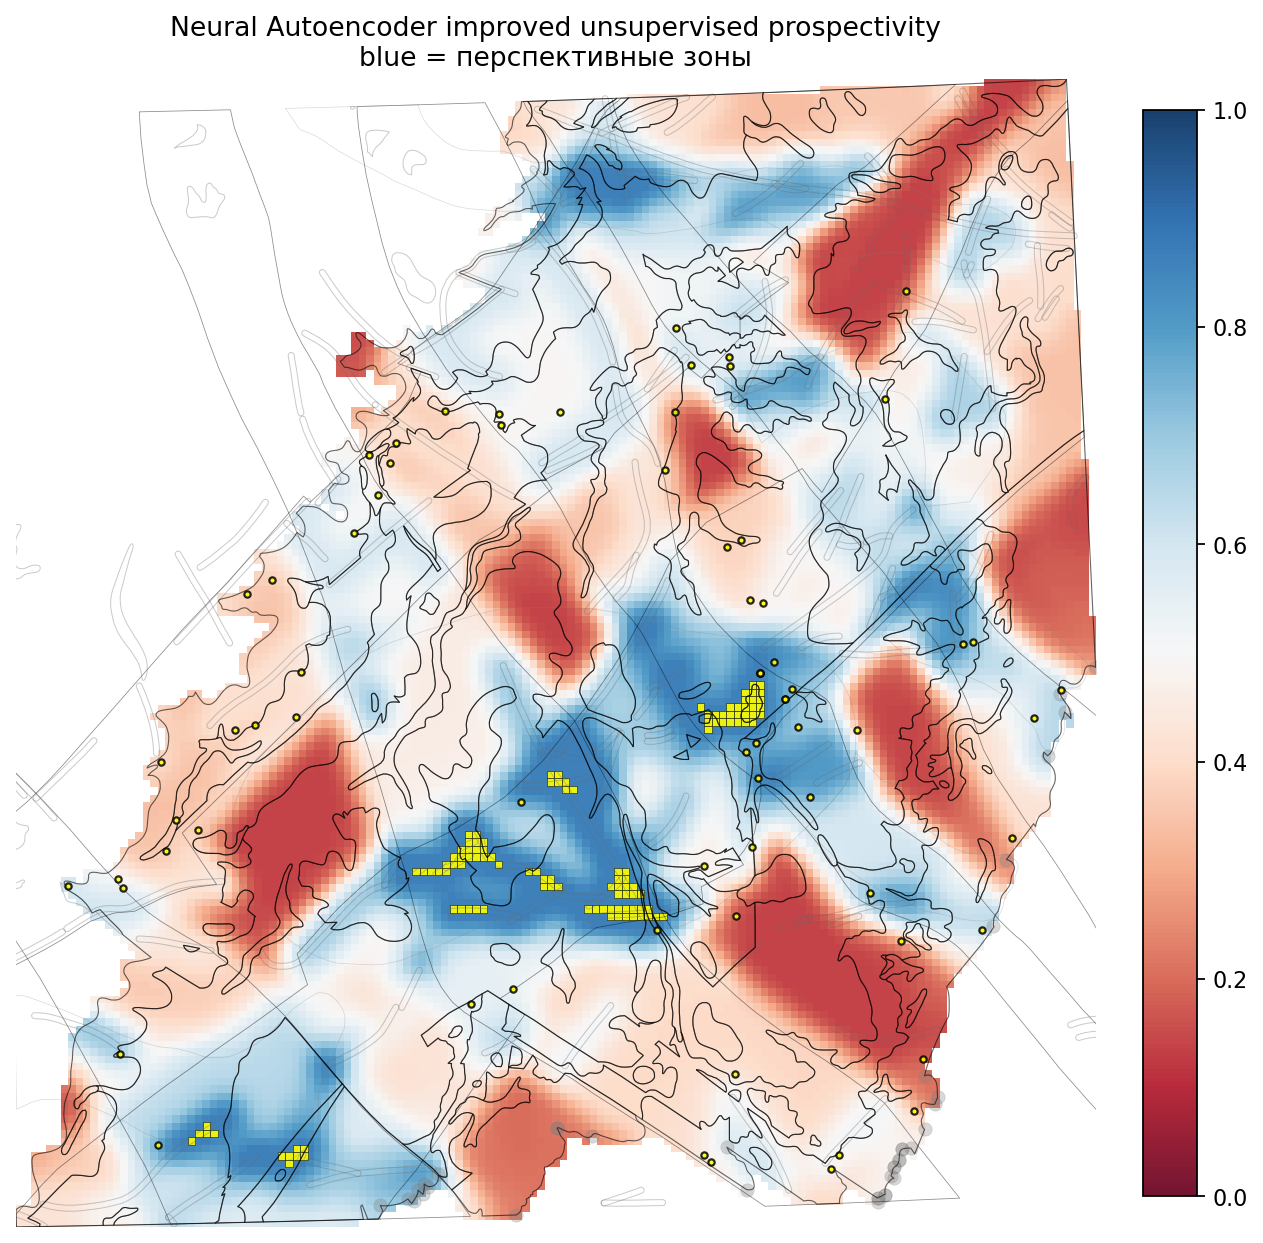

Сохранено PNG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\neural_autoencoder_unsupervised_improved_result\neural_autoencoder_unsupervised_improved_result.png


In [80]:
#
# Цвета: синий = более перспективно, красный = менее перспективно.


def make_display_score(arr, valid_mask, q_low=3, q_high=97, contrast=0.72):
    disp = arr.astype(float).copy()
    lo = np.nanpercentile(disp[valid_mask], q_low)
    hi = np.nanpercentile(disp[valid_mask], q_high)
    disp = np.clip(disp, lo, hi)
    disp = (disp - lo) / (hi - lo + 1e-9)
    disp = 0.5 + contrast * (disp - 0.5)
    disp = np.clip(disp, 0, 1)
    return np.where(valid_mask, disp, np.nan)


def plot_one_map():
    valid_mask = np.isfinite(prospectivity_arr)
    display_score = make_display_score(prospectivity_arr, valid_mask)
    extent = (minx, maxx, miny, maxy)

    fig, ax = plt.subplots(1, 1, figsize=(8, 9), dpi=160)
    im = ax.imshow(display_score, origin="lower", extent=extent, cmap="RdBu", vmin=0, vmax=1, alpha=0.92)
    ax.set_title("Neural Autoencoder improved unsupervised prospectivity\nblue = перспективные зоны", fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for key, color, lw, alpha in [
        ("tect1", "black", 0.35, 0.45),
        ("tect2", "black", 0.35, 0.45),
        ("magm", "dimgray", 0.45, 0.35),
        ("paleo", "gray", 0.30, 0.30),
        ("struct", "gray", 0.30, 0.30),
    ]:
        try:
            gdf = layers[LAYER_MAP[key]]
            if len(gdf) > 0:
                gdf.boundary.plot(ax=ax, color=color, linewidth=lw, alpha=alpha)
        except Exception:
            pass

    top_gdf = grid[grid["top_zone"] == 1].copy()
    if len(top_gdf) > 0:
        top_gdf.plot(ax=ax, color="yellow", edgecolor="black", linewidth=0.25, alpha=0.90, label="Top zone")

    if SHOW_POINTS and len(evidence_points_plot) > 0:
        evidence_points_plot.plot(ax=ax, color="yellow", edgecolor="black", markersize=8, alpha=0.85, zorder=5)

    try:
        layers[LAYER_MAP["mask"]].boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.6)
    except Exception:
        pass

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()

    out_png = OUT_DIR / "neural_autoencoder_unsupervised_improved_result.png"
    plt.savefig(out_png, bbox_inches="tight", dpi=220)
    plt.show()
    print("Сохранено PNG:", out_png)

plot_one_map()